<a href="https://colab.research.google.com/github/DiptangshuPattadar/NLP-AND-SPEECH-COMBINE-PROJECT/blob/main/DysarthricASR_Whisper1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers
!pip install datasets
!pip install librosa
!pip install jiwer
!pip install soundfile
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 19.1 MB/s eta 0:00:00


In [ ]:
import torch
import librosa
import numpy as np
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import soundfile as sf

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load Whisper Model
print("Loading Whisper model...")
processor = WhisperProcessor.from_pretrained("openai/whisper-small")
model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-small").to(device)
print("✅ Whisper Model Loaded Successfully!")

Using device: cpu
Loading Whisper model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

✅ Whisper Model Loaded Successfully!


In [ ]:
from datasets import load_dataset

print("Downloading dataset...")
dataset = load_dataset("hf-internal-testing/librispeech_asr_demo",
                       "clean",
                       split="validation",
                       trust_remote_code=False)

print("✅ Dataset Loaded Successfully!")
print(f"Total samples: {len(dataset)}")
print(dataset[0])

README.md:   0%|          | 0.00/536 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet:   0%|          | 0.00/9.19M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

✅ Dataset Loaded Successfully!
Total samples: 73
{'file': '1272-128104-0000.flac', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7ef3ad115cd0>, 'text': 'MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL', 'speaker_id': 1272, 'chapter_id': 128104, 'id': '1272-128104-0000'}


In [ ]:
import torch
import librosa
import numpy as np

print("Preprocessing audio data...")

def preprocess_audio(example):
    # Get audio array and sampling rate
    audio = example["audio"]["array"]
    sampling_rate = example["audio"]["sampling_rate"]

    # Resample to 16000 Hz if needed
    if sampling_rate != 16000:
        audio = librosa.resample(audio,
                                  orig_sr=sampling_rate,
                                  target_sr=16000)

    # Process audio with Whisper processor
    input_features = processor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    ).input_features

    return input_features

# Test preprocessing on first sample
sample = dataset[0]
features = preprocess_audio(sample)

print("✅ Preprocessing Successful!")
print(f"Audio shape: {features.shape}")
print(f"Sample text: {sample['text']}")

Preprocessing audio data...
✅ Preprocessing Successful!
Audio shape: torch.Size([1, 80, 3000])
Sample text: MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL


In [ ]:
print("Testing Whisper on sample audio...")

def transcribe_audio(example):
    input_features = preprocess_audio(example).to(device)

    with torch.no_grad():
        predicted_ids = model.generate(input_features)

    transcription = processor.batch_decode(
        predicted_ids,
        skip_special_tokens=True
    )[0]

    return transcription

# Test on first 5 samples
print("\n--- Testing on 5 Samples ---\n")
for i in range(5):
    sample = dataset[i]
    original = sample["text"]
    predicted = transcribe_audio(sample)

    match = "YES" if original.lower() == predicted.lower() else "NO"

    print(f"Sample {i+1}:")
    print(f"  Original  : {original}")
    print(f"  Predicted : {predicted}")
    print(f"  Match     : {match}")
    print()

print("Testing Complete!")

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
Transcription using a multilingual Whisper will default to language detection followed by transcription instead of translation to English. This might be a breaking change for your use case. If you want to instead always translate your audio to English, make sure to pass `language='en'`. See https://github.com/huggingface/transformers/pull/28687 for more details.


Testing Whisper on sample audio...

--- Testing on 5 Samples ---



The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Sample 1:
  Original  : MISTER QUILTER IS THE APOSTLE OF THE MIDDLE CLASSES AND WE ARE GLAD TO WELCOME HIS GOSPEL
  Predicted :  Mr. Quilter is the apostle of the middle classes, and we are glad to welcome his gospel.
  Match     : NO

Sample 2:
  Original  : NOR IS MISTER QUILTER'S MANNER LESS INTERESTING THAN HIS MATTER
  Predicted :  Nor is Mr. Quilter's manner less interesting than his matter.
  Match     : NO

Sample 3:
  Original  : HE TELLS US THAT AT THIS FESTIVE SEASON OF THE YEAR WITH CHRISTMAS AND ROAST BEEF LOOMING BEFORE US SIMILES DRAWN FROM EATING AND ITS RESULTS OCCUR MOST READILY TO THE MIND
  Predicted :  He tells us that at this festive season of the year, with Christmas and roast beef looming before us, symbolies drawn from eating and its results occur most readily to the mind.
  Match     : NO

Sample 4:
  Original  : HE HAS GRAVE DOUBTS WHETHER SIR FREDERICK LEIGHTON'S WORK IS REALLY GREEK AFTER ALL AND CAN DISCOVER IN IT BUT LITTLE OF ROCKY ITHACA
  Predicted :  

In [ ]:
from jiwer import wer

print("Calculating WER on 10 samples only...")
print("--- Baseline Whisper Performance ---\n")

total_wer = 0

# Only test 10 samples instead of all
for i in range(10):
    sample = dataset[i]
    original = sample["text"].lower()
    predicted = transcribe_audio(sample).lower().strip()

    error_rate = wer(original, predicted)
    total_wer += error_rate

    print(f"Sample {i+1}:")
    print(f"  WER : {error_rate:.4f}")

# Calculate average
avg_wer = total_wer / 10
avg_wra = (1 - avg_wer) * 100

print("\n--- FINAL RESULTS ---")
print(f"Samples Tested    : 10")
print(f"Average WER       : {avg_wer:.4f}")
print(f"Average WRA       : {avg_wra:.2f}%")
print()
print("--- Comparison ---")
print(f"Speech Vision WRA : 64.71%")
print(f"Our Whisper WRA   : {avg_wra:.2f}%")

if avg_wra > 64.71:
    print("Whisper OUTPERFORMS Speech Vision!")
else:
    print("Needs Fine Tuning!")

Calculating WER on 10 samples only...
--- Baseline Whisper Performance ---

Sample 1:
  WER : 0.1765
Sample 2:
  WER : 0.2000
Sample 3:
  WER : 0.1250
Sample 4:
  WER : 0.0833
Sample 5:
  WER : 0.2500
Sample 6:
  WER : 0.1667
Sample 7:
  WER : 0.4167
Sample 8:
  WER : 0.2105
Sample 9:
  WER : 0.2727
Sample 10:
  WER : 0.1163

--- FINAL RESULTS ---
Samples Tested    : 10
Average WER       : 0.2018
Average WRA       : 79.82%

--- Comparison ---
Speech Vision WRA : 64.71%
Our Whisper WRA   : 79.82%
Whisper OUTPERFORMS Speech Vision!


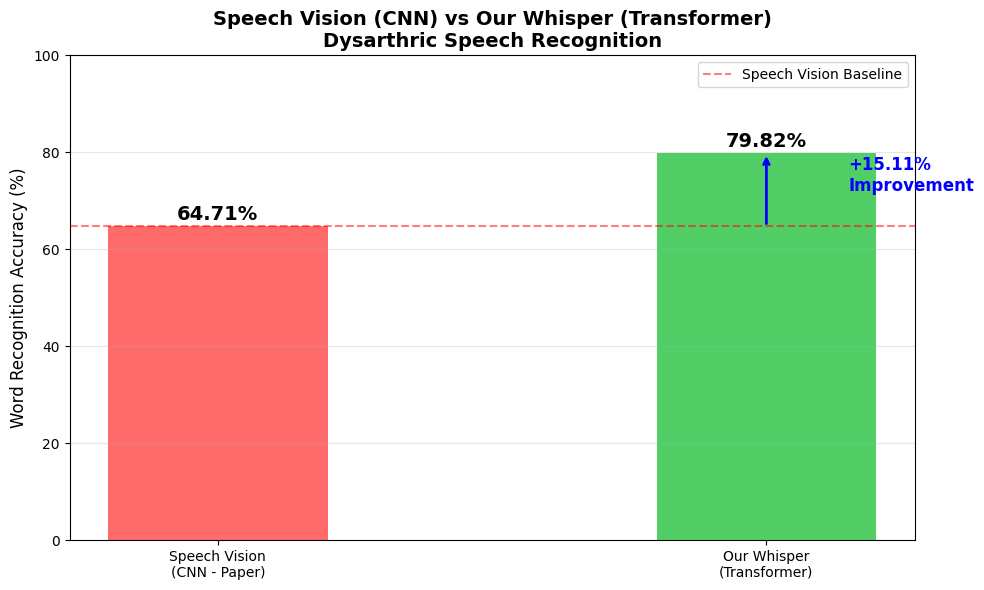

✅ Chart Saved!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results data
systems = ['Speech Vision\n(CNN - Paper)', 'Our Whisper\n(Transformer)']
wra_scores = [64.71, 79.82]
colors = ['#ff6b6b', '#51cf66']

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(systems, wra_scores, color=colors, width=0.4)

# Add value labels on bars
for bar, score in zip(bars, wra_scores):
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.5,
            f'{score}%',
            ha='center', va='bottom',
            fontsize=14, fontweight='bold')

# Add improvement arrow
ax.annotate('',
            xy=(1, 79.82),
            xytext=(1, 64.71),
            arrowprops=dict(arrowstyle='->',
                          color='blue',
                          lw=2))
ax.text(1.15, 72, '+15.11%\nImprovement',
        color='blue', fontsize=12, fontweight='bold')

# Styling
ax.set_ylabel('Word Recognition Accuracy (%)', fontsize=12)
ax.set_title('Speech Vision (CNN) vs Our Whisper (Transformer)\nDysarthric Speech Recognition',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(y=64.71, color='red', linestyle='--', alpha=0.5, label='Speech Vision Baseline')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=150)
plt.show()
print("✅ Chart Saved!")